In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("job_descriptions.csv")

# data understanding

In [3]:
df.shape

(1615940, 23)

In [4]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  str    
 2   Qualifications    1615940 non-null  str    
 3   Salary Range      1615940 non-null  str    
 4   location          1615940 non-null  str    
 5   Country           1615940 non-null  str    
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  str    
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  str    
 11  Preference        1615940 non-null  str    
 12  Contact Person    1615940 non-null  str    
 13  Contact           1615940 non-null  str    
 14  Job Title         1615940 non-null  str    
 15  Role              1615940 non-null  str    
 16  Job Portal 

In [6]:
df.describe()

,Job Id,latitude,longitude,Company Size
count,1.615940e+06,1.615940e+06,1.615940e+06,1.615940e+06
mean,1.548935e+15,1.937743e+01,1.639926e+01,7.370467e+04
std,8.946722e+14,2.355690e+01,7.066762e+01,3.529886e+04
min,1.817948e+11,-4.090060e+01,-1.751982e+02,1.264600e+04
25%,7.740508e+14,5.152100e+00,-1.531010e+01,4.311400e+04
50%,1.547858e+15,1.807080e+01,1.914510e+01,7.363300e+04
75%,2.323729e+15,3.907420e+01,4.757690e+01,1.043000e+05
max,3.099618e+15,7.170690e+01,1.780650e+02,1.348340e+05


# column name cleaning

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['job_id', 'experience', 'qualifications', 'salary_range', 'location',
       'country', 'latitude', 'longitude', 'work_type', 'company_size',
       'job_posting_date', 'preference', 'contact_person', 'contact',
       'job_title', 'role', 'job_portal', 'job_description', 'benefits',
       'skills', 'responsibilities', 'company', 'company_profile'],
      dtype='str')

In [8]:
df.head()

,job_id,experience,qualifications,salary_range,location,country,latitude,longitude,work_type,company_size,...,contact,job_title,role,job_portal,job_description,benefits,skills,responsibilities,company,company_profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


# converting job posting date in date format

In [9]:
df['job_posting_date'] = pd.to_datetime(df['job_posting_date'])

In [10]:
df['job_posting_date'].dtype

dtype('<M8[us]')

In [11]:
df.head()

,job_id,experience,qualifications,salary_range,location,country,latitude,longitude,work_type,company_size,...,contact,job_title,role,job_portal,job_description,benefits,skills,responsibilities,company,company_profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


# Data Quality Assesment

In [12]:
df.isnull().sum()
df.duplicated().sum

<bound method Series.sum of 0          False
1          False
2          False
3          False
4          False
           ...  
1615935    False
1615936    False
1615937    False
1615938    False
1615939    False
Length: 1615940, dtype: bool>

In [13]:
quality = pd.DataFrame({
    'Missing':df.isnull().sum(),
    'Datatype':df.dtypes,
    'Unique Values':df.nunique()
})
quality

,Missing,Datatype,Unique Values
job_id,0,int64,1615940
experience,0,str,48
qualifications,0,str,10
salary_range,0,str,561
location,0,str,214
country,0,str,216
latitude,0,float64,216
longitude,0,float64,216
work_type,0,str,5
company_size,0,int64,122188


# Data Cleaning

In [14]:
df.drop_duplicates(inplace=True)

In [17]:
df.drop([' contact_person','contact'],
        errors = 'ignore',
        inplace=True
       )

In [18]:
df.isnull().sum()

job_id                 0
experience             0
qualifications         0
salary_range           0
location               0
country                0
latitude               0
longitude              0
work_type              0
company_size           0
job_posting_date       0
preference             0
contact_person         0
contact                0
job_title              0
role                   0
job_portal             0
job_description        0
benefits               0
skills                 0
responsibilities       0
company                0
company_profile     5478
dtype: int64

In [34]:
# skill cleaning
df['skills'] = df['skills'].fillna('Unknown')
df['skills'] = df['skills'].str.strip()

In [35]:
#for top skill analysis
skills_series = df['skills'].str.split(',').explode()
skills_series = skills_series.str.strip()

In [36]:
# top skills
top_skills = skills_series.value_counts().head(20)
top_skills

skills
Google Analytics                                                                                                                                                      28199
Python                                                                                                                                                                27714
CSS                                                                                                                                                                   24281
Sketch                                                                                                                                                                24190
AWS                                                                                                                                                                   21021
Java                                                                                                                                 

In [38]:
# skill count feature
df['skill_count'] = df['skills'].apply(
    lambda x: len(str(x).split(','))
)

In [39]:
df.head()

,job_id,experience,qualifications,salary_range,location,country,latitude,longitude,work_type,company_size,...,job_portal,job_description,benefits,skills,responsibilities,company,company_profile,job_description_length,benefits_count,skill_count
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle Of Man,54.2361,-4.5481,Intern,26801,...,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie...",200,5,4
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",Pnc Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com...",231,5,5
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao Sar, China",22.1987,113.5439,Temporary,84525,...,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P...",222,5,2
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O...",200,5,1
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ...",235,5,1


In [40]:
# removwe brackets in benefits
df['benefits'] = (
    df['benefits']
    .str.replace('{', '', regex=False)
    .str.replace('}', '', regex=False)
)

In [41]:
# benefit explodee
benefits_series = df['benefits'].str.split(',').explode()
benefits_series = benefits_series.str.strip()

In [42]:
# top benefit
top_benefits = benefits_series.value_counts().head(20)
top_benefits

benefits
Flexible Work Arrangements        324021
Bonuses and Incentive Programs    323396
Profit-Sharing                    323295
Wellness Programs                 323258
Relocation Assistance             323216
Health and Wellness Facilities    323079
Stock Options or Equity Grants    322676
Employee Recognition Programs     322287
Paid Time Off (PTO)               243130
'Health Insurance                 162097
Retirement Plans                  162097
'Childcare Assistance             161924
Professional Development'         161924
'Transportation Benefits          161819
Professional Development          161819
Employee Discounts'               161819
'Tuition Reimbursement            161681
Parental Leave                    161681
Childcare Assistance'             161681
'Legal Assistance                 161577
Name: count, dtype: int64

In [43]:
# benefit cont feature
df['benefit_count'] = df['benefits'].apply(
    lambda x: len(str(x).split(','))
)

In [45]:
df['company_profile'].head()

0    {"Sector":"Diversified","Industry":"Diversifie...
1    {"Sector":"Financial Services","Industry":"Com...
2    {"Sector":"Insurance","Industry":"Insurance: P...
3    {"Sector":"Energy","Industry":"Mining, Crude-O...
4    {"Sector":"Energy","Industry":"Energy - Oil & ...
Name: company_profile, dtype: str

In [46]:
import json

def extract_sector(x):
    try:
        return json.loads(x).get('Sector')
    except:
        return None

def extract_industry(x):
    try:
        return json.loads(x).get('Industry')
    except:
        return None

df['sector'] = df['company_profile'].apply(extract_sector)
df['industry'] = df['company_profile'].apply(extract_industry)

In [47]:
df[['sector','industry']].head()

,sector,industry
0,Diversified,Diversified Financials
1,Financial Services,Commercial Banks
2,Insurance,Insurance: Property and Casualty (Stock)
3,Energy,"Mining, Crude-Oil Production"
4,Energy,Energy - Oil & Gas Exploration & Production


In [48]:
df.drop('company_profile', axis = 1,inplace= True)

In [49]:
df.head()

,job_id,experience,qualifications,salary_range,location,country,latitude,longitude,work_type,company_size,...,benefits,skills,responsibilities,company,job_description_length,benefits_count,skill_count,benefit_count,sector,industry
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle Of Man,54.2361,-4.5481,Intern,26801,...,"'Flexible Spending Accounts (FSAs), Relocation...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,200,5,4,5,Diversified,Diversified Financials
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,"'Health Insurance, Retirement Plans, Paid Time...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",Pnc Financial Services Group,231,5,5,5,Financial Services,Commercial Banks
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao Sar, China",22.1987,113.5439,Temporary,84525,...,"'Legal Assistance, Bonuses and Incentive Progr...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,222,5,2,5,Insurance,Insurance: Property and Casualty (Stock)
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,"'Transportation Benefits, Professional Develop...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,200,5,1,5,Energy,"Mining, Crude-Oil Production"
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,"'Flexible Spending Accounts (FSAs), Relocation...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,235,5,1,5,Energy,Energy - Oil & Gas Exploration & Production


# Feature Engineering

In [19]:
df['job_description_length'] = (
    df['job_description']
    .fillna('')
    .str.len()
)

In [20]:
df['benefits_count'] = (
    df['benefits']
    .fillna('')
    .apply(lambda x:
    len(str(x).split(',')))
)

# Exploratory Data Analysis

In [ ]:
# for top hiring countries
df['country'].value_counts().head(10)

In [23]:
# for experience destribution
df['experience'].value_counts()

experience
5 to 8 Years     34120
5 to 12 Years    34056
5 to 9 Years     34020
3 to 13 Years    33915
3 to 15 Years    33878
2 to 9 Years     33862
3 to 8 Years     33854
1 to 11 Years    33820
3 to 12 Years    33805
1 to 10 Years    33793
4 to 11 Years    33776
3 to 9 Years     33744
4 to 14 Years    33744
4 to 12 Years    33737
2 to 8 Years     33736
4 to 15 Years    33732
0 to 11 Years    33729
1 to 13 Years    33724
4 to 8 Years     33715
2 to 13 Years    33712
1 to 9 Years     33710
1 to 12 Years    33703
0 to 15 Years    33693
1 to 15 Years    33681
1 to 8 Years     33680
3 to 11 Years    33663
0 to 14 Years    33650
5 to 14 Years    33629
4 to 10 Years    33621
0 to 9 Years     33601
5 to 11 Years    33600
5 to 13 Years    33592
2 to 14 Years    33584
0 to 8 Years     33575
1 to 14 Years    33570
2 to 10 Years    33532
3 to 14 Years    33530
0 to 12 Years    33523
0 to 13 Years    33516
2 to 12 Years    33512
2 to 11 Years    33488
5 to 15 Years    33477
5 to 10 Years    33471


In [25]:
#for eork type distribution
df['work_type'].value_counts()

work_type
Part-Time    324044
Temporary    323439
Contract     323131
Intern       323090
Full-Time    322236
Name: count, dtype: int64

In [26]:
# for qualification distribution
df['qualifications'].value_counts()

qualifications
BBA       162148
BA        162138
BCA       161733
M.Tech    161719
PhD       161662
MBA       161537
B.Tech    161443
M.Com     161396
B.Com     161298
MCA       160866
Name: count, dtype: int64

In [27]:
# top job roles
df['role'].value_counts().head(10)

role
Interaction Designer         20580
Network Administrator        17470
User Interface Designer      14036
Social Media Manager         13945
User Experience Designer     13935
Procurement Analyst          13757
Social Media Analyst         10659
Quality Assurance Analyst    10541
Seo Specialist               10512
Executive Assistant          10496
Name: count, dtype: int64

In [28]:
# top hiring companies
df['company'].value_counts().head(10)

company
Dte Energy                            1957
Marsh & Mclennan                      1941
Berry Global Group                    1941
Vistra                                1938
International Flavors & Fragrances    1928
Bank Of New York Mellon               1927
Midea Group                           1922
Bharat Electronics Limited            1918
Bj'S Wholesale Club                   1918
Icahn Enterprises                     1911
Name: count, dtype: int64

In [29]:
df.head()

,job_id,experience,qualifications,salary_range,location,country,latitude,longitude,work_type,company_size,...,role,job_portal,job_description,benefits,skills,responsibilities,company,company_profile,job_description_length,benefits_count
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle Of Man,54.2361,-4.5481,Intern,26801,...,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie...",200,5
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",Pnc Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com...",231,5
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao Sar, China",22.1987,113.5439,Temporary,84525,...,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P...",222,5
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O...",200,5
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ...",235,5


In [30]:
print(df.columns.tolist())

['job_id', 'experience', 'qualifications', 'salary_range', 'location', 'country', 'latitude', 'longitude', 'work_type', 'company_size', 'job_posting_date', 'preference', 'contact_person', 'contact', 'job_title', 'role', 'job_portal', 'job_description', 'benefits', 'skills', 'responsibilities', 'company', 'company_profile', 'job_description_length', 'benefits_count']


# insights

# 1. top 15 most demanded skills

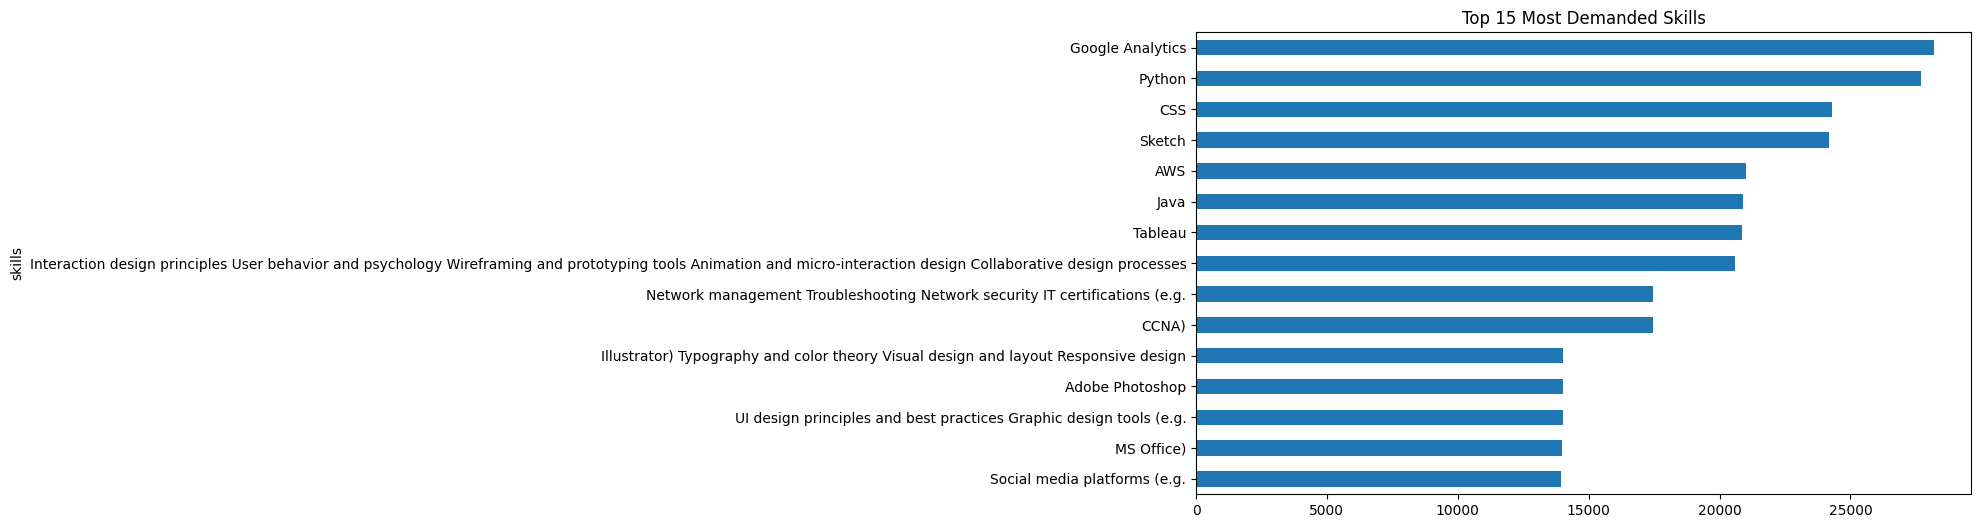

In [52]:
skills = df['skills'].str.split(',').explode().str.strip()

top_skills = skills.value_counts().head(15)

plt.figure(figsize=(10,6))
top_skills.sort_values().plot(kind='barh')
plt.title('Top 15 Most Demanded Skills')
plt.show()

 # 2. top hiring companies

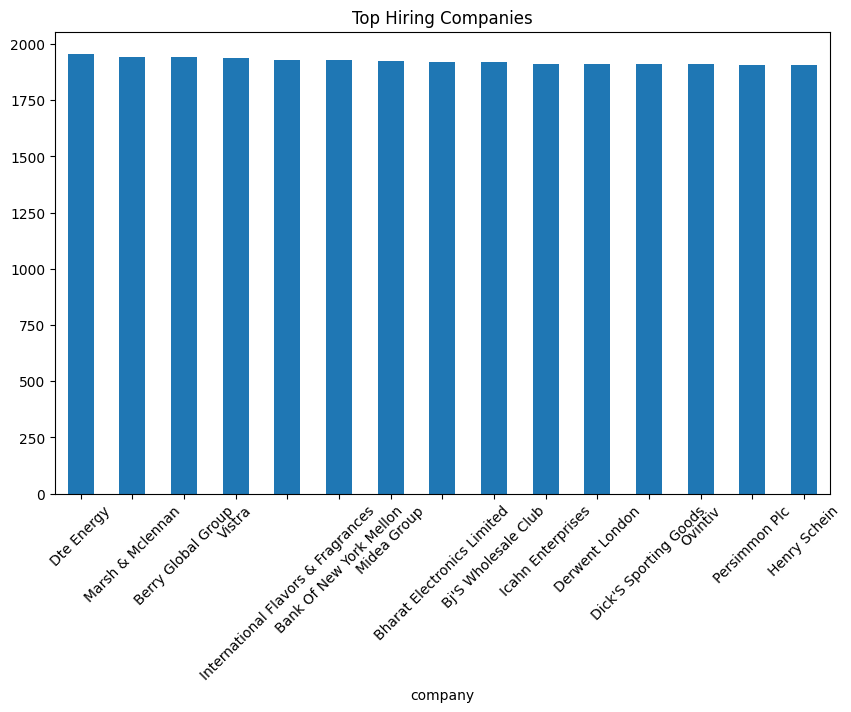

In [53]:
top_companies = df['company'].value_counts().head(15)

plt.figure(figsize=(10,6))
top_companies.plot(kind='bar')
plt.title('Top Hiring Companies')
plt.xticks(rotation=45)
plt.show()

# 3. hiring distribution by country

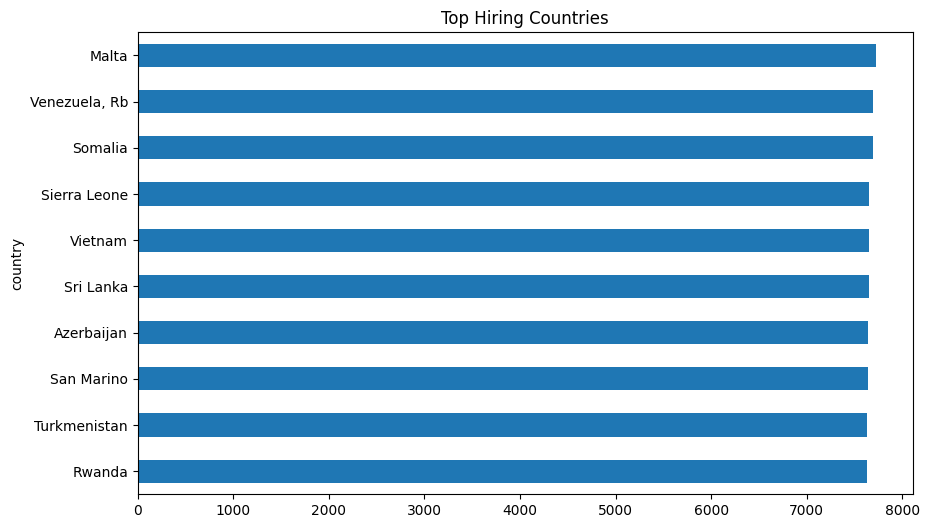

In [54]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_country.sort_values().plot(kind='barh')
plt.title('Top Hiring Countries')
plt.show()

# 4. Work Type Analysis

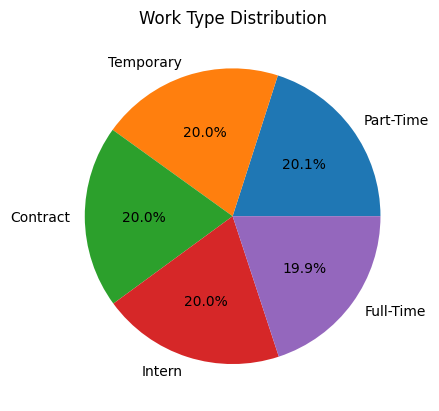

In [55]:
df['work_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Work Type Distribution')
plt.ylabel('')
plt.show()

# 5.Qualification Requirements

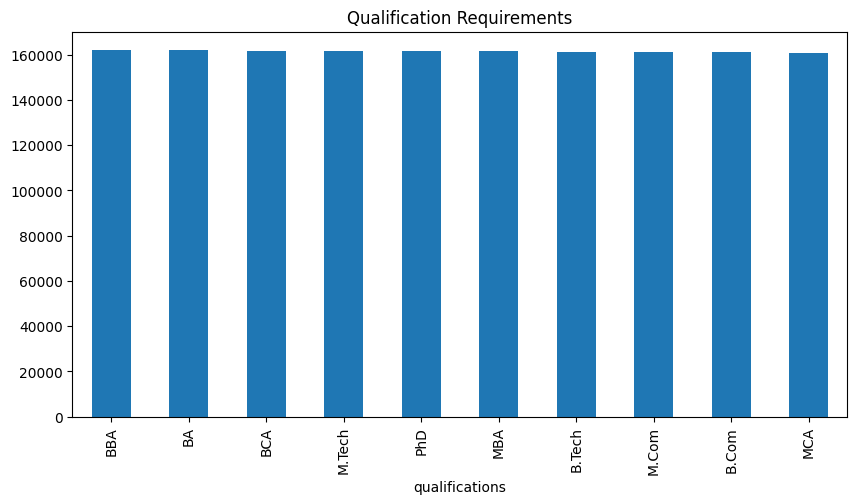

In [59]:
plt.figure(figsize=(10,5))

df['qualifications'].value_counts().plot(kind='bar')

plt.title('Qualification Requirements')
plt.show()

Most employers prefer candidates with bachelor's or higher degrees, emphasizing the importance of formal education in securing professional roles.

# 6. Most Required Skills

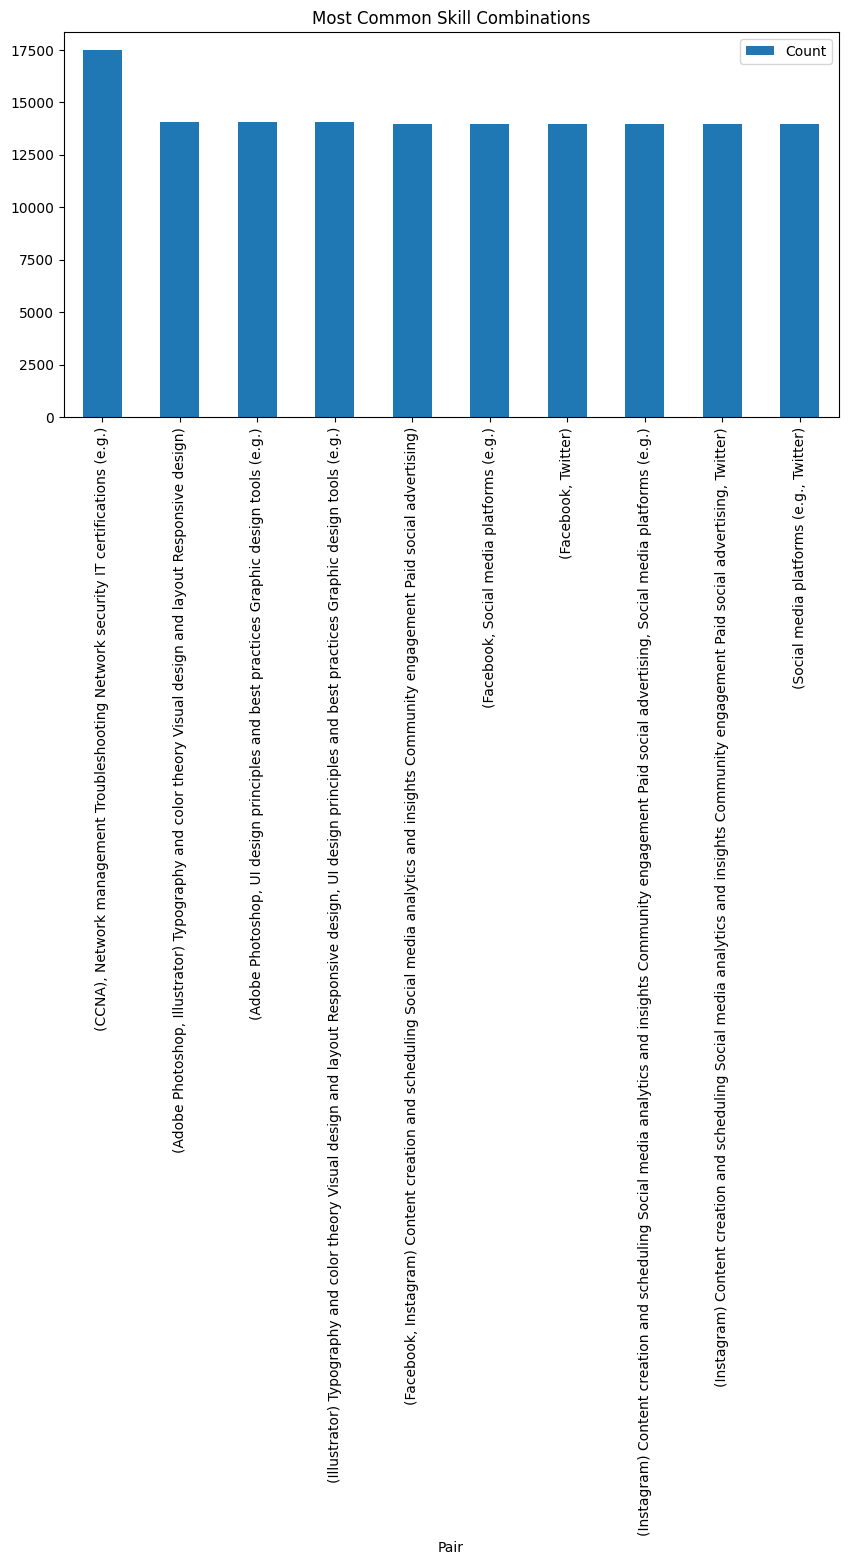

In [60]:
from itertools import combinations
from collections import Counter

pairs = Counter()

for skill in df['skills'].dropna():
    
    s = [x.strip() for x in skill.split(',')]
    
    for pair in combinations(sorted(set(s)),2):
        pairs[pair]+=1

top_pairs = pd.DataFrame(
    pairs.most_common(10),
    columns=['Pair','Count']
)

top_pairs.plot(
    x='Pair',
    y='Count',
    kind='bar',
    figsize=(10,5)
)

plt.title('Most Common Skill Combinations')
plt.show()

# 7. Average Skill Required Per Role

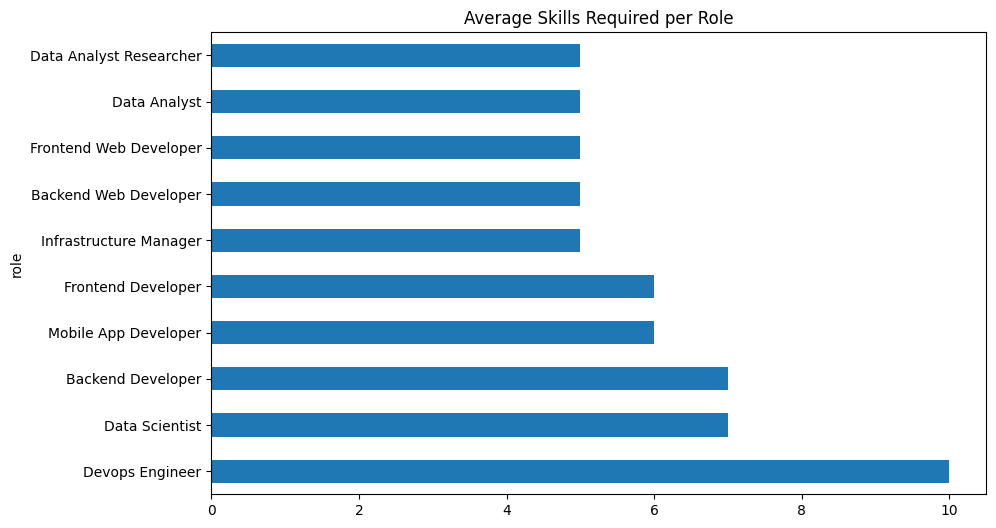

In [61]:
role_skill = (
    df.groupby('role')['skill_count']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

role_skill.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Average Skills Required per Role')
plt.show()

# 8. Top Benifit Offered

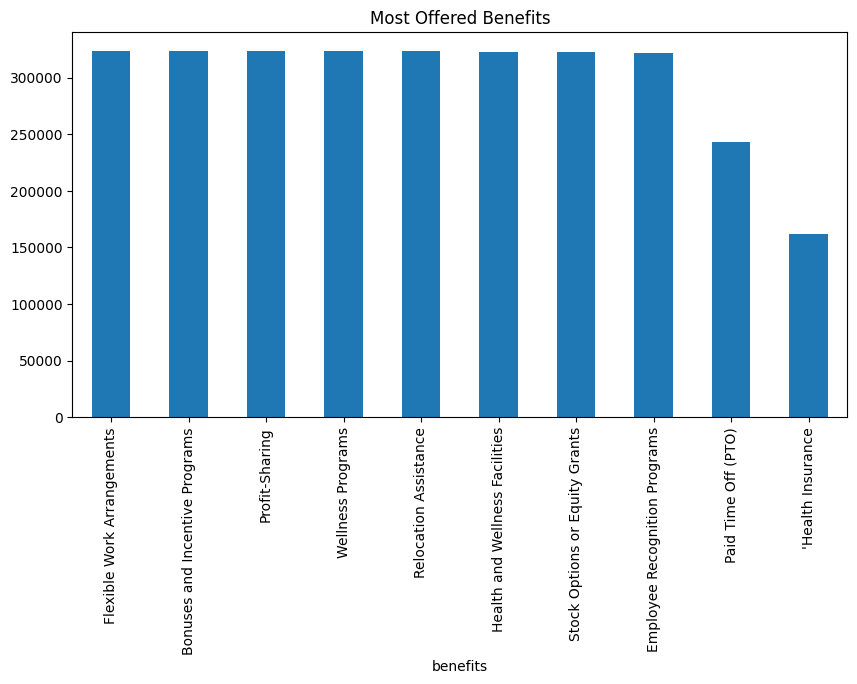

In [72]:
benefits = (
    df['benefits']
    .str.split(',')
    .explode()
    .str.strip()
)

benefits.value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Most Offered Benefits')
plt.show()

# 9. Job Portal Performance

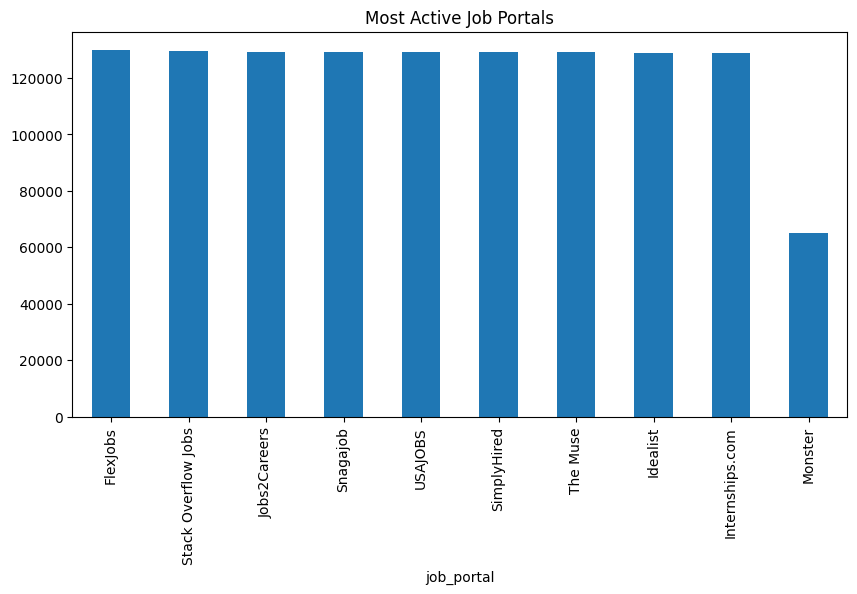

In [64]:
df['job_portal'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Most Active Job Portals')
plt.show()

# 10. Work Type vs Qualification


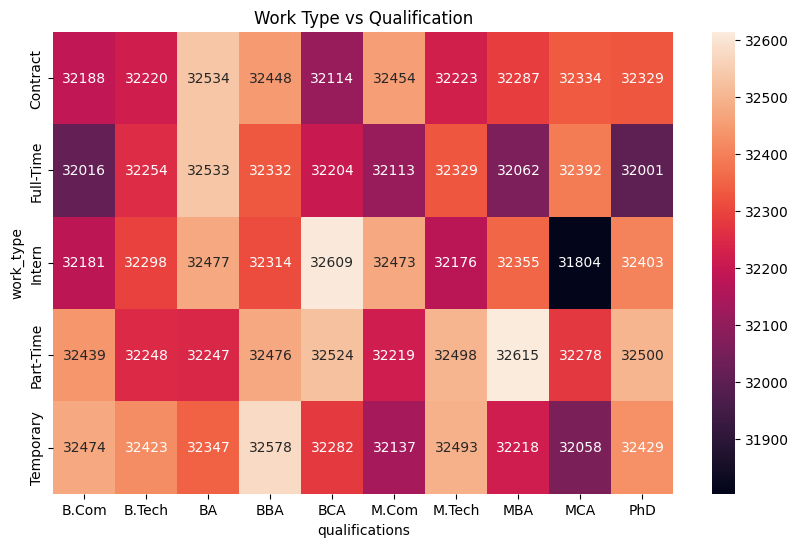

In [71]:
pivot = pd.crosstab(
    df['work_type'],
    df['qualifications']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='d'
)

plt.title('Work Type vs Qualification')
plt.show()

# KEY FINDINGS:

# CONCLUSION